# Main Notebook for producing results

In [13]:
import pandas as pd 
import matplotlib.pyplot as plt

PATH = "/Users/madshaakonsson/Desktop/5. Semester/special/hmm-code/data/b1.csv"



DELIMITER = ";"


df = pd.read_csv(
    PATH,
    sep=DELIMITER,
    na_values=["NA"],
    on_bad_lines="skip",  # drop extra fields
)

df

,obs,Time,Day,Month,Room,WindowClosed,Hour,NoPresenceDwelling,WinCloseAction,WinOpenAction,OutdoorTemp,Wind,OutdoorRH,SolRad,SolTimer,TempC,RHC,LuxC,CO2C,DewPtC,day
1,1,0.509826,4,1,Bedroom,NaN,12,NaN,0,0,-2.4,8.0,78,19,0.00,18.057,38.499,59.1,1021.2500,3.722,0
2,2,0.516771,4,1,Bedroom,NaN,12,NaN,0,0,-2.4,8.0,78,19,0.00,18.033,35.361,35.5,750.3125,2.500,0
3,3,0.523715,4,1,Bedroom,NaN,12,NaN,0,0,-2.5,10.1,76,21,0.00,17.605,35.015,19.7,630.3125,1.984,0
4,4,0.530660,4,1,Bedroom,NaN,12,NaN,0,0,-2.5,10.1,76,21,0.00,17.249,35.083,35.5,601.2500,1.696,0
5,5,0.537604,4,1,Bedroom,NaN,12,NaN,0,0,-2.5,10.1,76,21,0.00,17.034,35.639,19.7,570.3125,1.727,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43025,10851,0.826389,1,6,Livingroom,0.0,19,NaN,0,0,20.3,4.0,27,234,14.85,26.720,29.539,43.4,529.0625,7.495,149
43026,10852,0.833333,1,6,Livingroom,0.0,20,NaN,0,0,20.3,4.0,27,234,14.85,26.671,29.677,43.4,558.1250,7.521,149
43027,10853,0.840278,1,6,Livingroom,0.0,20,NaN,0,0,20.3,4.0,27,234,14.85,26.622,29.816,43.4,558.1250,7.548,149
43028,10854,0.847222,1,6,Livingroom,0.0,20,NaN,0,0,20.3,4.0,27,234,14.85,26.426,30.263,35.5,527.5000,7.597,149


In [26]:
df["Room"].unique()

<StringArray>
['Bedroom', 'Livingroom']
Length: 2, dtype: str

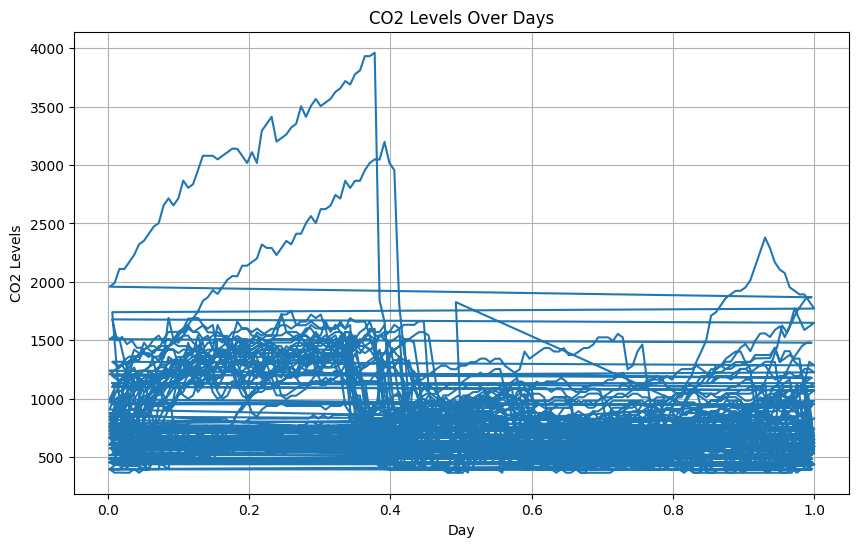

In [19]:
# Plotting Co2 vs Time up to day 35
plt.figure(figsize=(10, 6))
df_35 = df[df["day"] <= 35]
plt.plot(df_35["Time"], df_35["CO2C"])


plt.title("CO2 Levels Over Days")
plt.xlabel("Day")
plt.ylabel("CO2 Levels")
plt.grid()
plt.show()

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Expect these already loaded (match your R objects):
# win1_agr: DataFrame with columns "Time" and "Hour"
# filt_utt: numpy array or DataFrame with columns [0,1,2] like filt$Utt

t = win1_agr["Time"].to_numpy()
hour0 = float(win1_agr["Hour"].iloc[0])
x = t + hour0 / 24.0

# Ensure filt_utt is a 2D numpy array
U = np.asarray(filt_utt)

plt.figure(figsize=(7, 4), facecolor="white")
plt.plot(x, U, color="white")  # invisible line, matches R's matplot(..., col="white")

# grayscale colors like R: gray(c(0, 0.5, 0.9))
col_tmp = ["#000000", "#808080", "#E6E6E6"]

plt.fill_between(x, 0, U[:, 0], color=col_tmp[0], linewidth=0)
plt.fill_between(x, U[:, 0], U[:, 0] + U[:, 1], color=col_tmp[1], linewidth=0)
plt.fill_between(x, U[:, 0] + U[:, 1], 1, color=col_tmp[2], linewidth=0)

plt.xlabel("Time [days]")
plt.ylabel(r"$\hat{u}_{t|t}$")
plt.tight_layout()
plt.show()

NameError: name 'win1_agr' is not defined